## Data Exploration on 7k Books

Let's for perform a data exploration for 7k Books Dataset where try to understand dataset compostion how to use it.

In [1]:
# Loading the libararies
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import kagglehub
from itables import init_notebook_mode;
init_notebook_mode(all_interactive=True)

In [2]:
# Download latest version
path = kagglehub.dataset_download("dylanjcastillo/7k-books-with-metadata")
print("Path to dataset files:", path)

Path to dataset files: C:\Users\Kishore\.cache\kagglehub\datasets\dylanjcastillo\7k-books-with-metadata\versions\3


In [3]:
# Loading the dataset
books = pd.read_csv(f"{path}/books.csv")
# Saving the Dataset in Raw
books.to_csv("../data/raw/7k-books.csv")

In [4]:
# Loading head
books.head()

Loading ITables v2.7.3 from the init_notebook_mode cell... (need help?)


In [5]:
books.describe(include="all")

Loading ITables v2.7.3 from the init_notebook_mode cell... (need help?)


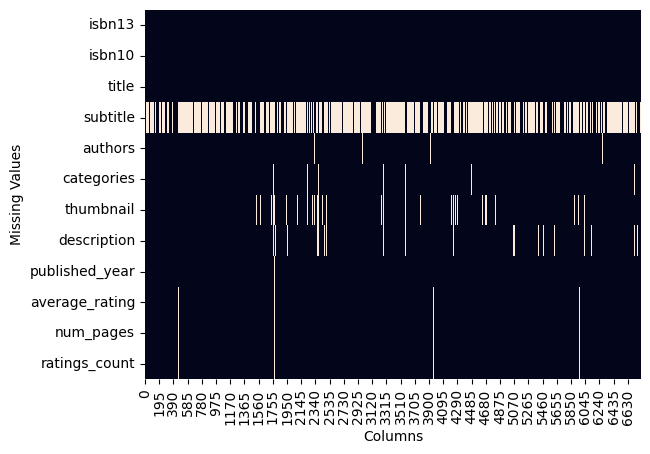

In [6]:
# Plotting Heat Map to see a missing values
ax = plt.axes()
sns.heatmap(books.isna().transpose(), cbar=False, ax=ax)

plt.xlabel("Columns")
plt.ylabel("Missing Values")

plt.show()

In [7]:
# Creating Missing Description and Features
books["missing_description"] = np.where(books["description"].isna(), 1,0)
books["age_of_book"] = 2026 - books["published_year"]

In [8]:
# Books columns in list
books.columns.to_list()

['isbn13',
 'isbn10',
 'title',
 'subtitle',
 'authors',
 'categories',
 'thumbnail',
 'description',
 'published_year',
 'average_rating',
 'num_pages',
 'ratings_count',
 'missing_description',
 'age_of_book']

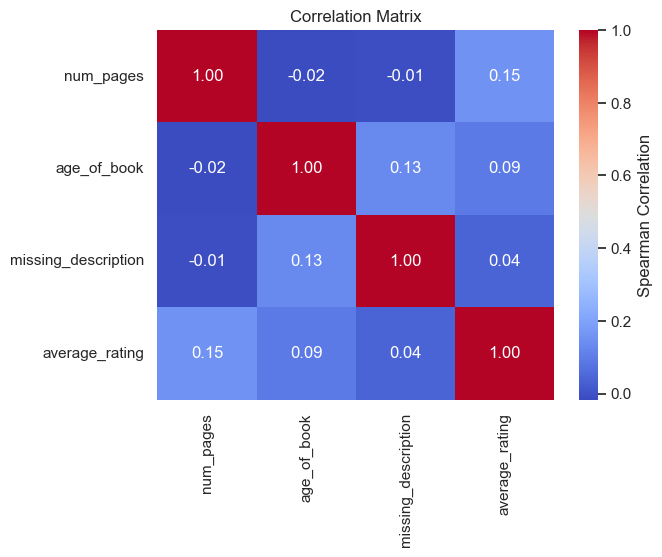

In [9]:
columns_of_intrests = ["num_pages", "age_of_book", "missing_description", 'average_rating']

correlation_matrix = books[columns_of_intrests].corr(method="spearman")
sns.set_theme(style="white")
heatmap = sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            cbar_kws={'label': 'Spearman Correlation'})
heatmap.set_title("Correlation Matrix")
plt.show()

Removing the missing Values

In [10]:
# Checking null values
books[["description", "num_pages", "average_rating", "published_year"]].isnull().sum()

Loading ITables v2.7.3 from the init_notebook_mode cell... (need help?)


In [11]:
missing_books=books[(books["description"].isna())  | 
    (books["num_pages"].isna())     | 
    (books["average_rating"].isna()) |
    (books["published_year"].isna())]

len(missing_books)

303

In [12]:
missing_books["categories"].value_counts().reset_index().sort_values('count', ascending=False)

Loading ITables v2.7.3 from the init_notebook_mode cell... (need help?)


In [13]:
# Dataset with out missing values
not_missing_books=books[~(books["description"].isna())  &
    ~(books["num_pages"].isna())      & 
    ~(books["average_rating"].isna())  &
    ~(books["published_year"].isna())]

len(not_missing_books)

6507

In [14]:
not_missing_books

Loading ITables v2.7.3 from the init_notebook_mode cell... (need help?)


In [15]:
not_missing_books["categories"].value_counts().reset_index().sort_values('count', ascending=False)

Loading ITables v2.7.3 from the init_notebook_mode cell... (need help?)


In [16]:
not_missing_books["no_of_word_description"] = not_missing_books["description"].str.split().str.len()
not_missing_books.head()

Loading ITables v2.7.3 from the init_notebook_mode cell... (need help?)


In [17]:
not_missing_books.loc[not_missing_books["no_of_word_description"].between(1,4), "description"]

Loading ITables v2.7.3 from the init_notebook_mode cell... (need help?)


In [18]:
not_missing_books.loc[not_missing_books["no_of_word_description"].between(5,14), "description"]

Loading ITables v2.7.3 from the init_notebook_mode cell... (need help?)


In [19]:
not_missing_books.loc[not_missing_books["no_of_word_description"].between(25,34), "description"]

Loading ITables v2.7.3 from the init_notebook_mode cell... (need help?)


In [20]:
book_not_missing_25_words = not_missing_books[not_missing_books["no_of_word_description"]>=25]

In [21]:
book_not_missing_25_words.describe(include="all")

Loading ITables v2.7.3 from the init_notebook_mode cell... (need help?)


In [22]:
# Create temporary series to ensure we are working with clean strings
t = book_not_missing_25_words["title"].astype(str)
s = book_not_missing_25_words["subtitle"].fillna("").astype(str)

# Join them: if subtitle is empty, just title; else, title: subtitle
book_not_missing_25_words["title_and_subtitles"] = np.where(
    s == "", 
    t, 
    t + ": " + s
)

In [23]:
book_not_missing_25_words.head()

Loading ITables v2.7.3 from the init_notebook_mode cell... (need help?)


In [24]:
book_not_missing_25_words.columns.to_list()

['isbn13',
 'isbn10',
 'title',
 'subtitle',
 'authors',
 'categories',
 'thumbnail',
 'description',
 'published_year',
 'average_rating',
 'num_pages',
 'ratings_count',
 'missing_description',
 'age_of_book',
 'no_of_word_description',
 'title_and_subtitles']

In [25]:
book_not_missing_25_words["tagged_description"] = book_not_missing_25_words[["isbn13", "description"]].astype(str).agg(" ".join, axis=1)

In [26]:
book_not_missing_25_words["tagged_description"].head()

Loading ITables v2.7.3 from the init_notebook_mode cell... (need help?)


In [27]:
# dropping unwanted columns
book_not_missing_25_words.drop(['missing_description', 
'age_of_book', 'no_of_word_description'], axis=1).to_csv("../data/processed/book_cleaned.csv", index=False)

In [28]:
book_not_missing_25_words.head()

Loading ITables v2.7.3 from the init_notebook_mode cell... (need help?)
